<!--
Copyright (c) 2024 - 2025 Advanced Micro Devices, Inc. All rights reserved.

See LICENSE for license information.
-->

# Use the TraceLens perf model **without a trace**

## Context

In normal use, TraceLens fuses two sources per kernel:

- the **perf model** supplies analytical **FLOPs and bytes** from the op's shapes and dtypes,
- the **trace** supplies the measured **wall-clock time**.

Dividing one by the other gives the **achieved TFLOPs/s and TB/s** that fill every cell of
every TraceLens perf report. The perf model is the analytical half; the trace is the
empirical half.

What makes the analytical half valuable is **breadth of op coverage**. The perf model
already has curated formulas for the fundamental op classes you actually hit in modern
workloads — `GEMM`, `SDPA`, `CONV`, `Softmax`, `Normalization`, `GroupedGemm`, `MoEComm`,
`MambaSSD`, `FusedRoPE`, `CrossEntropy`, `CausalConv1d`, plus the elementwise and reduction
primitives — over a dozen base classes in total, all maintained and tested against real
traces.

The perf model is just a Python library — you can call it directly. **No trace needed.**
Hand it shapes, get back FLOPs and bytes; arithmetic intensity and roofline-bounded time
follow for free. Useful for sizing studies, end-to-end ceilings, and regression bounds —
without launching a kernel.

This notebook is a small worked example: Llama-3-70B on MI300X, only `GEMM` and `SDPA`, no trace.

## Three parts

1. **GEMM** — every linear in a decoder layer, plotted as `AI(M)`.
2. **SDPA** — attention forward and backward across sequence length.
3. **Llama-3-70B per-token rollup** — predicted ms-per-token for decode and prefill (bf16, MI300X).

Closes [#206](https://github.com/AMD-AGI/TraceLens/issues/206).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from TraceLens.PerfModel.perf_model import GEMM, SDPA

# MI300X specs (matrix-bf16 MAF + HBM3 BW). Source:
# https://rocm.blogs.amd.com/software-tools-optimization/measuring-max-achievable-flops-part2/
PEAK_TFLOPS_BF16 = 708.0      # matrix bf16 MAF (TFLOPs/s)
HBM_BW_GBPS      = 5300.0     # HBM3 bandwidth (GB/s)

# Crossover arithmetic intensity (FLOPs/byte) — below this you're memory-bound.
AI_KNEE_BF16 = (PEAK_TFLOPS_BF16 * 1e12) / (HBM_BW_GBPS * 1e9)
print(f"MI300X roofline knee (bf16) = {AI_KNEE_BF16:5.0f} FLOPs/byte")

# Llama-3-70B config (public model card)
LLAMA = dict(
    hidden=8192,
    ffn=28672,
    n_q_heads=64,
    n_kv_heads=8,
    head_dim=128,
    vocab=128256,
    n_layers=80,
)
LLAMA["q_proj_out"]  = LLAMA["n_q_heads"]  * LLAMA["head_dim"]   # 8192
LLAMA["kv_proj_out"] = LLAMA["n_kv_heads"] * LLAMA["head_dim"]   # 1024

BPE_BF16 = 2  # bytes per element for bf16


def predict_time_us(flops, bytes_, peak_tflops, hbm_bw_gbps):
    """Roofline upper bound on per-op runtime, in microseconds.

    Returns (us, regime) where regime is "compute" or "memory" — i.e. which
    side of the roofline this op is bounded by at the given peak/BW.

    Implicit assumption: perfect overlap of compute and memory traffic within
    the kernel, so achievable time is `max(t_compute, t_memory)`. This is the
    same model TraceLens' built-in roofline analysis uses, just with shapes
    you provide instead of shapes pulled from a profile.
    """
    t_compute = (flops  / 1e12) / peak_tflops    * 1e6
    t_memory  = (bytes_ / 1e9)  / hbm_bw_gbps    * 1e6
    return max(t_compute, t_memory), ("compute" if t_compute >= t_memory else "memory")


LLAMA

MI300X roofline knee (bf16) =   134 FLOPs/byte


{'hidden': 8192,
 'ffn': 28672,
 'n_q_heads': 64,
 'n_kv_heads': 8,
 'head_dim': 128,
 'vocab': 128256,
 'n_layers': 80,
 'q_proj_out': 8192,
 'kv_proj_out': 1024}

## Part 1 — GEMM: every linear in a Llama-3-70B decoder layer

For each matmul in a Llama-3-70B layer + `lm_head`, the perf model gives us:

- `GEMM.flops_func(M, N, K, bias)` → `2·M·N·K` (+ bias)
- `GEMM.bytes_func(M, N, K, bias, bpe_*)` → bytes moved (read A, read B, write C)

Their ratio is **arithmetic intensity** — FLOPs/byte — which tells us whether the kernel is
HBM-bound or matrix-core-bound. Both methods are plain `@staticmethod`s, so you don't need a
profile to call them.

In [2]:
def llama_linears(cfg):
    """(name, K, N, bias) for every linear in a Llama-3-70B decoder layer + lm_head.

    Convention: Y = X @ W where X is (M, K), W is (K, N), M = B · S.
    """
    h, ffn = cfg["hidden"], cfg["ffn"]
    return [
        ("q_proj",    h,                 cfg["q_proj_out"],  False),
        ("k_proj",    h,                 cfg["kv_proj_out"], False),
        ("v_proj",    h,                 cfg["kv_proj_out"], False),
        ("o_proj",    cfg["q_proj_out"], h,                  False),
        ("gate_proj", h,                 ffn,                False),
        ("up_proj",   h,                 ffn,                False),
        ("down_proj", ffn,               h,                  False),
        ("lm_head",   h,                 cfg["vocab"],       False),
    ]


# One concrete shape (B=8, S=2048, bf16) — what does the perf model say per linear?
M, bpe = 8 * 2048, 2
rows = []
for name, K, N, _ in llama_linears(LLAMA):
    flops  = GEMM.flops_func(M, N, K, False)
    bytes_ = GEMM.bytes_func(M, N, K, False, bpe, bpe, bpe, bpe)
    rows.append({"layer": name, "M": M, "N": N, "K": K,
                 "TFLOPs": flops / 1e12, "GB": bytes_ / 1e9, "AI": flops / bytes_})
pd.DataFrame(rows).set_index("layer").round({"TFLOPs": 2, "GB": 2, "AI": 1})

,M,N,K,TFLOPs,GB,AI
layer,,,,,,
q_proj,16384,8192,8192,2.20,0.67,3276.8
k_proj,16384,1024,8192,0.27,0.32,862.3
v_proj,16384,1024,8192,0.27,0.32,862.3
o_proj,16384,8192,8192,2.20,0.67,3276.8
gate_proj,16384,28672,8192,7.70,1.68,4587.5
up_proj,16384,28672,8192,7.70,1.68,4587.5
down_proj,16384,8192,28672,7.70,1.68,4587.5
lm_head,16384,128256,8192,34.43,6.57,5238.3


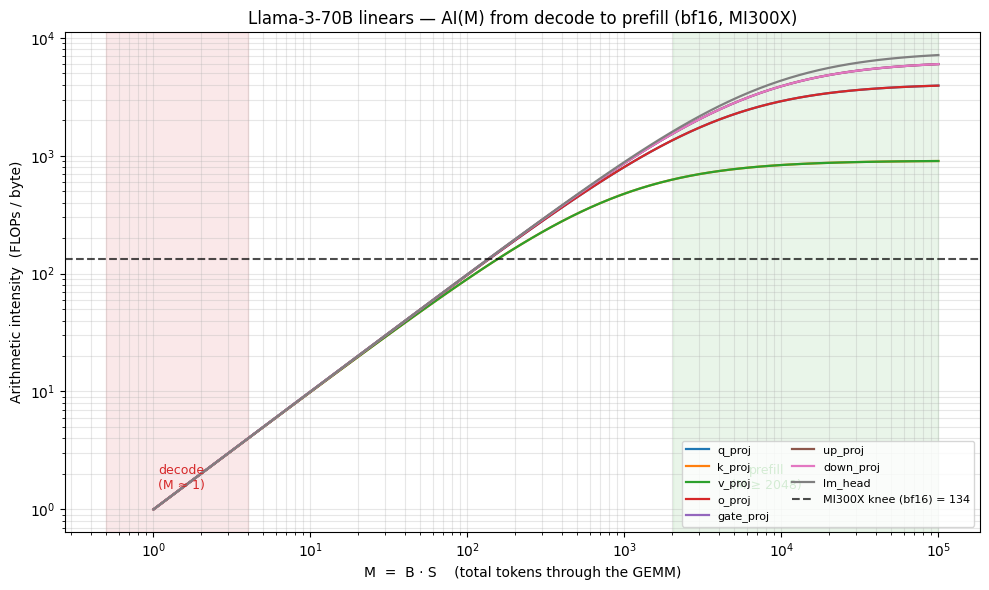

In [3]:
# Sweep total token count M = B * S over the full range from decode (M=1)
# to long-context prefill (M ~ 100k).  We plot AI(M) per layer in bf16 and
# overlay the bf16 roofline knee so the regime crossover is on-screen.
M_sweep = np.unique(np.logspace(0, 5, 80, dtype=int))

fig, ax = plt.subplots(figsize=(10, 6))
for name, K, N, bias in llama_linears(LLAMA):
    ai_curve = []
    for M in M_sweep:
        flops  = GEMM.flops_func(M, N, K, bias)
        bytes_ = GEMM.bytes_func(M, N, K, bias, 2, 2, 2, 2)
        ai_curve.append(flops / bytes_)
    ax.plot(M_sweep, ai_curve, lw=1.6, label=name)

ax.axhline(AI_KNEE_BF16, linestyle="--", color="k", alpha=0.7,
           label=f"MI300X knee (bf16) = {AI_KNEE_BF16:.0f}")
ax.axvspan(0.5, 4,        alpha=0.10, color="C3")
ax.axvspan(2048, 1e5,     alpha=0.10, color="C2")
ax.text(1.5,    1.5,  "decode\n(M ≈ 1)",            fontsize=9, color="C3", ha="center")
ax.text(8000,   1.5,  "prefill\n(M ≥ 2048)",         fontsize=9, color="C2", ha="center")

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("M  =  B · S    (total tokens through the GEMM)")
ax.set_ylabel("Arithmetic intensity  (FLOPs / byte)")
ax.set_title("Llama-3-70B linears — AI(M) from decode to prefill (bf16, MI300X)")
ax.grid(True, which="both", alpha=0.3)
ax.legend(loc="lower right", fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

### What to read off the GEMM plot

- **Decode (M ≈ 1, red)** — every linear has AI ≈ 1, well below the knee. Bandwidth-bound.
- **Prefill (M ≥ 2048, green)** — every linear above the knee. Matrix-core-bound.
- The **crossover** happens around `M ≈ 64 – 256` depending on shape: FFN layers cross
  earliest, `lm_head` crosses latest (its enormous `N = 128 256` keeps it memory-heavy).
- AI grows ~linearly with `M` in the small-M regime, then plateaus at `2·N·K / (N+K)`.

### Same op, three regimes

The plot above shows the regimes visually. Numerically, here's `q_proj` (8192×8192×8192) at
the three canonical inference points: decode, batched decode, prefill. Same kernel, three
completely different regimes — predicted without launching anything.

In [4]:
def gemm_one_op(label, M, N, K):
    bpe = BPE_BF16
    flops  = GEMM.flops_func(M, N, K, False)
    bytes_ = GEMM.bytes_func(M, N, K, False, bpe, bpe, bpe, bpe)
    us, regime = predict_time_us(flops, bytes_, PEAK_TFLOPS_BF16, HBM_BW_GBPS)
    return {
        "regime_label": label, "M": M, "N": N, "K": K,
        "TFLOPs": flops / 1e12, "GB": bytes_ / 1e9,
        "AI": flops / bytes_, "us_pred": us, "bound_by": regime,
    }


q_proj_K, q_proj_N = LLAMA["hidden"], LLAMA["q_proj_out"]   # 8192, 8192
regimes_df = pd.DataFrame([
    gemm_one_op("decode (B=1, S=1)",            1,    q_proj_N, q_proj_K),
    gemm_one_op("batched decode (B=128, S=1)",  128,  q_proj_N, q_proj_K),
    gemm_one_op("prefill (B=1, S=2048)",        2048, q_proj_N, q_proj_K),
])
regimes_df.round({"TFLOPs": 4, "GB": 4, "AI": 1, "us_pred": 1})

,regime_label,M,N,K,TFLOPs,GB,AI,us_pred,bound_by
0,"decode (B=1, S=1)",1,8192,8192,0.0001,0.1343,1.0,25.3,memory
1,"batched decode (B=128, S=1)",128,8192,8192,0.0172,0.1384,124.1,26.1,memory
2,"prefill (B=1, S=2048)",2048,8192,8192,0.2749,0.2013,1365.3,388.2,compute


## Part 2 — SDPA (attention)

Llama-3-70B uses GQA: 64 Q heads, 8 KV heads, head_dim 128, causal. Sweep `S` and ask the
perf model for forward + backward FLOPs / bytes / AI / predicted-us. (Backward uses
`flash_impl=True` to model the recomputed QK^T.)

In [5]:
def sdpa_metrics(B, S, H_Q=64, H_KV=8, d_h=128, causal=True):
    """Forward + backward FLOPs / bytes / AI / predicted-us for one SDPA call (bf16)."""
    bpe = BPE_BF16
    flops_fwd = SDPA.flops_func(B, S, H_Q, S, H_KV, d_h, d_h, causal)
    bytes_fwd = SDPA.bytes_func(B, S, H_Q, S, H_KV, d_h, d_h, causal, bpe)
    flops_bwd = SDPA.flops_bwd_func(B, S, H_Q, S, H_KV, d_h, d_h, causal, flash_impl=True)
    bytes_bwd = SDPA.bytes_bwd_func(B, S, H_Q, S, H_KV, d_h, d_h, causal, bpe)
    us_fwd, _ = predict_time_us(flops_fwd, bytes_fwd, PEAK_TFLOPS_BF16, HBM_BW_GBPS)
    us_bwd, _ = predict_time_us(flops_bwd, bytes_bwd, PEAK_TFLOPS_BF16, HBM_BW_GBPS)
    return {
        "TFLOPs_fwd": flops_fwd / 1e12, "GB_fwd": bytes_fwd / 1e9,
        "AI_fwd":     flops_fwd / bytes_fwd, "us_fwd": us_fwd,
        "TFLOPs_bwd": flops_bwd / 1e12, "GB_bwd": bytes_bwd / 1e9,
        "AI_bwd":     flops_bwd / bytes_bwd, "us_bwd": us_bwd,
    }


rows = []
for B in [1, 4, 16, 64]:
    for S in [64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384]:
        rows.append({"B": B, "S": S, **sdpa_metrics(B, S)})
df_sdpa = pd.DataFrame(rows)
df_sdpa.query("B == 1").set_index("S").drop(columns="B").round(2)

,TFLOPs_fwd,GB_fwd,AI_fwd,us_fwd,TFLOPs_bwd,GB_bwd,AI_bwd,us_bwd
S,,,,,,,,
64,0.00,0.00,28.44,0.45,0.00,0.00,45.73,0.69
128,0.00,0.00,56.89,0.89,0.00,0.01,91.44,1.38
256,0.00,0.01,113.78,1.78,0.00,0.01,182.87,3.79
512,0.00,0.02,227.56,6.07,0.01,0.03,365.73,15.17
1024,0.02,0.04,455.11,24.27,0.04,0.06,731.44,60.66
2048,0.07,0.08,910.22,97.06,0.17,0.12,1462.87,242.66
4096,0.27,0.15,1820.44,388.25,0.69,0.23,2925.73,970.62
8192,1.10,0.30,3640.89,1552.98,2.75,0.47,5851.44,3882.47
16384,4.40,0.60,7281.78,6211.93,11.00,0.94,11702.87,15529.85


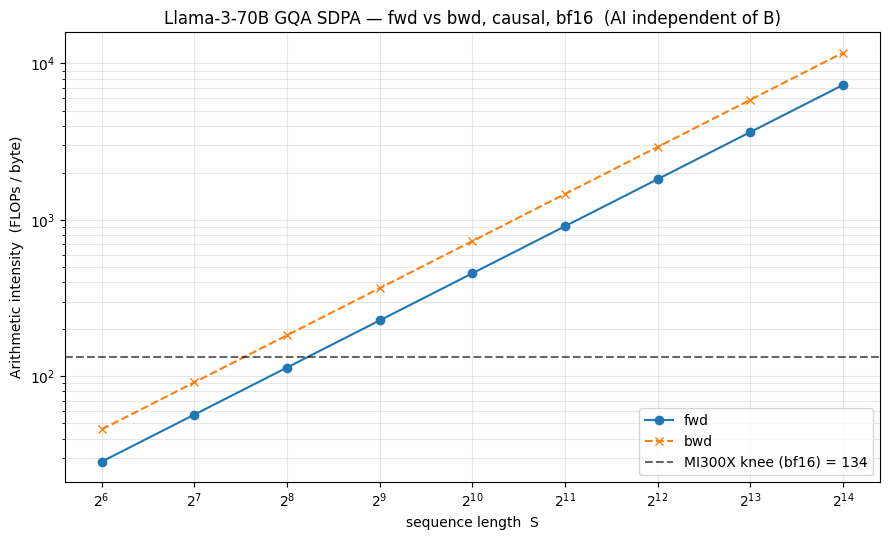

In [6]:
g = df_sdpa[df_sdpa.B == 1]
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(g["S"], g["AI_fwd"], marker="o", color="C0", label="fwd")
ax.plot(g["S"], g["AI_bwd"], marker="x", color="C1", linestyle="--", label="bwd")
ax.axhline(AI_KNEE_BF16, linestyle="--", color="k", alpha=0.6,
           label=f"MI300X knee (bf16) = {AI_KNEE_BF16:.0f}")
ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.set_xlabel("sequence length  S")
ax.set_ylabel("Arithmetic intensity  (FLOPs / byte)")
ax.set_title("Llama-3-70B GQA SDPA — fwd vs bwd, causal, bf16  (AI independent of B)")
ax.grid(True, which="both", alpha=0.3)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Reading the SDPA plot

- AI scales linearly with `S` (compute is `O(S²)`, bytes are `O(S)`), so the crossover from
  memory- to compute-bound lands around **`S ≈ 256–512`** for forward and earlier for backward.
- AI is independent of `B` in GQA SDPA — all B curves overlap.
- Backward AI is ~1.6× higher than forward because flash-attention recomputation amortises
  the same Q/K/V loads across more FLOPs.

> **Decode-style SDPA** (`N_Q=1` with a growing KV cache) sits in a different regime:
> AI ≈ `2·H_Q / (H_Q + 2·H_KV) / bpe` ≈ **8 in bf16**, *regardless* of context length —
> always memory-bound by KV-cache reads. That's why paged attention, KV quantisation, and
> KV-cache offload are the high-leverage decode optimisations.

## Part 3 — Llama-3-70B per-token estimate (no trace, no kernel launch)

Roll up the per-op predicted-times across 80 decoder layers + `lm_head` to get a roofline
upper bound on full-forward cost. Two regimes:

- **Decode** (`B=1, S_q=1`, KV cache of 2048): every linear memory-bound → tokens/sec ceiling
  for single-stream inference.
- **Prefill** (`B=1, S=2048`, causal): everything compute-bound → prompt-processing throughput.

> **Scope.** This rollup counts only the GEMMs and SDPA — the dominant cost. RMSNorm,
> residual adds, RoPE, SwiGLU activation, and other elementwise ops are skipped for
> simplicity (each is small individually; together they're a few percent). All have
> their own perf models in TraceLens; adding them is a one-liner per op.

The roofline is an upper bound — a real kernel won't reach it. But the *ratios* between
layers and regimes are the useful planning numbers, and they fall out of pure arithmetic.

In [7]:
def predict_full_forward_us(S_q, S_kv):
    """Predicted us per op for one Llama-3-70B forward = 80 layers + lm_head (bf16).

    Returns (total_us, per_op_breakdown). Linears repeat 80x except lm_head (1x).
    """
    bpe = BPE_BF16
    brk = {}
    for name, K, N, _ in llama_linears(LLAMA):
        flops  = GEMM.flops_func(S_q, N, K, False)
        bytes_ = GEMM.bytes_func(S_q, N, K, False, bpe, bpe, bpe, bpe)
        brk[name], _ = predict_time_us(flops, bytes_, PEAK_TFLOPS_BF16, HBM_BW_GBPS)
    causal = (S_q == S_kv)
    f = SDPA.flops_func(1, S_q, LLAMA["n_q_heads"], S_kv, LLAMA["n_kv_heads"],
                        LLAMA["head_dim"], LLAMA["head_dim"], causal)
    b = SDPA.bytes_func(1, S_q, LLAMA["n_q_heads"], S_kv, LLAMA["n_kv_heads"],
                        LLAMA["head_dim"], LLAMA["head_dim"], causal, bpe)
    brk["sdpa"], _ = predict_time_us(f, b, PEAK_TFLOPS_BF16, HBM_BW_GBPS)
    total = sum(v * (1 if k == "lm_head" else LLAMA["n_layers"]) for k, v in brk.items())
    return total, brk


print("Llama-3-70B forward, MI300X roofline upper bound (bf16)")
print("-" * 56)
breakdowns = {}
scenarios = [
    ("decode  (1 tok, KV=2048)",    1,    2048, 1),
    ("prefill (2048 tok, causal)", 2048, 2048, 2048),
]
for label, S_q, S_kv, n_tok in scenarios:
    total_us, brk = predict_full_forward_us(S_q, S_kv)
    print(f"  {label:<28}  {total_us/1000:7.2f} ms   "
          f"({n_tok * 1e6 / total_us:8.1f} tok/s)")
    breakdowns[label.split()[0]] = brk

print("\nPer-op breakdown (us; lm_head counts once per forward, others ×80):")
pd.DataFrame(breakdowns).round(1)

Llama-3-70B forward, MI300X roofline upper bound (bf16)
--------------------------------------------------------
  decode  (1 tok, KV=2048)        26.36 ms   (    37.9 tok/s)
  prefill (2048 tok, causal)     409.85 ms   (  4996.9 tok/s)

Per-op breakdown (us; lm_head counts once per forward, others ×80):


,decode,prefill
q_proj,25.3,388.2
k_proj,3.2,48.5
v_proj,3.2,48.5
o_proj,25.3,388.2
gate_proj,88.6,1358.9
up_proj,88.6,1358.9
down_proj,88.6,1358.9
lm_head,396.5,6078.5
sdpa,1.6,97.1


## Takeaways

1. **The perf model gives you decisions, not just numbers.** Every FLOPs/byte/us value here
   came from a `@staticmethod` call — same code TraceLens runs over every event in a captured
   trace, just with shapes you provide.
2. **Decode is bandwidth-bound, prefill is compute-bound.** The same `q_proj` GEMM moves three
   orders of magnitude in AI between the two regimes — the predicted-ms numbers fall out automatically.
3. **MI300X Llama-3-70B bf16 ceilings as a one-page calc**: ~38 tok/s decode,
   ~5.0 ktok/s prefill — fully analytical, no allocation, no Slurm.

### This was a tiny slice — the perf model covers far more

Only `GEMM` and `SDPA` were demoed here. The same `flops_func` / `bytes_func` interface
exists on **every** base class in `TraceLens.PerfModel.perf_model`:

- **Compute**: `GEMM`, `GroupedGemm`, `CONV`, `jax_conv`
- **Attention**: `SDPA`, `Softmax`
- **Normalisation**: `Normalization`
- **MoE**: `MoEComm`
- **State-space / convs**: `MambaSSD`, `CausalConv1d`
- **Pointwise**: `UnaryElementwise`, `BinaryElementwise`, `Reduce`
- **Loss / embeddings**: `CrossEntropy`, `FusedRoPE`

The same "call `flops_func`, `bytes_func`, divide for AI, compare to roofline knee" playbook
works for every one of them.

### When this stops being enough

The roofline is an upper bound — useful for ceilings and sanity checks, less so for tight
predictions. TraceLens has tighter knobs for that; a follow-up notebook will cover them.